# Linear Regression - recitation

``
In this short excersice, you will experience with implementing linear regression for 2D points.
It may give you a deeper understanding about the limits this model has, and how it works.
``

## Imports

In [4]:
from sklearn.datasets import make_regression
from matplotlib import pyplot as plt
import numpy as np

## Generate Data

In [5]:
NOISE = 15
NUM_SAMPLES = 100

X, y = make_regression(n_samples=NUM_SAMPLES, n_features=1, noise=NOISE)
y = np.resize(y,(NUM_SAMPLES,1))
X.transpose();

## Plot Data

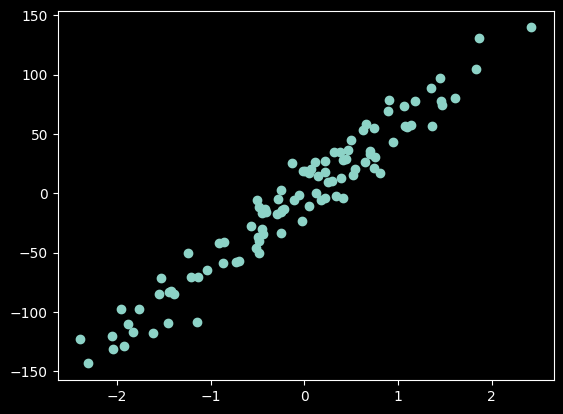

In [6]:
plt.scatter(X, y)

## Implement Linear Regression

```
If you remember, the simple Linear Regression in 2D defined as follows:

Two arrays: X = {x_1, x_2, ..., x_n}, Y = {y_1, y_2, ..., y_n}
The goal is to find values b,m such that the cost function:
```

$$Loss(b,m) = \frac{1}{n}\overset{n}{\underset{i=1}{\sum}} (m x_i + b - y_i)^2$$

```
is minimal.
The way to do it is by derivating Loss(b,m):
```
$$\frac{dL(b,m)}{db} = \frac{1}{n}\overset{n}{\underset{i=1}{\sum}} 2(m x_i + b - y_i), \hspace{1cm} \frac{dL(b,m)}{dm} = \frac{1}{n}\overset{n}{\underset{i=1}{\sum}} 2x_i(m x_i + b - y_i)$$

```
And do gradient steps with it:
```

$$b_{j+1} = b_{j} - \alpha \frac{dL(b_j,m_j)}{db}, \hspace{1cm} m_{j+1} = m_{j} - \alpha \frac{dL(b_j,m_j)}{dm}$$

($\alpha$ = learning rate)

In [20]:
def linear_regression(X, y, m_current=0, b_current=0, epochs=10000, learning_rate=0.0001):
    N = float(len(y)) # Number of examples
    
    m_list = [m_current]
    b_list = [b_current]
    
    # Perform Gradient (GD)
    for i in range(epochs):
        # Evaluate current model
        y_current = m_current*X+b_current
        cost = np.mean(y_current-y)**2
        
        # Calculate Gradient
        m_gradient = np.mean(2*X*(m_current*X+b_current-y))
        b_gradient = np.mean(2*(m_current*X+b_current-y))
        
        # Make one GD step
        m_current = m_current-learning_rate*m_gradient
        b_current = b_current-learning_rate*b_gradient
         
        m_list.append(m_current)
        b_list.append(b_current)
          
    return m_current, b_current, cost, m_list, b_list

## Do Regression

In [21]:
m, b, cost, m_list, b_list = linear_regression(X, y, # The examples
                                               m_current=10, b_current=-10, # The starting point for m and b
                                               learning_rate=0.3, # The learning rate, will be discussed later
                                               epochs=50 # Number of GD steps
                                              )

## Plot data and learned model line

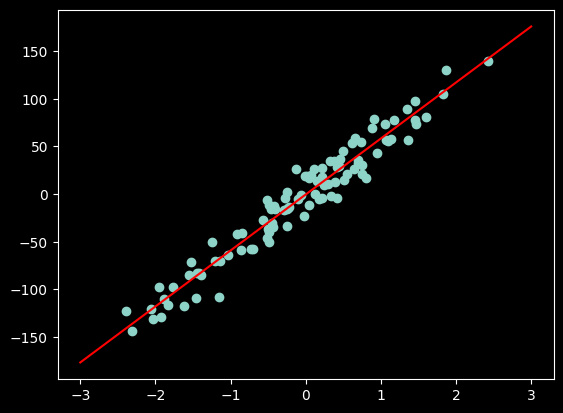

In [22]:
# Plot data
plt.scatter(X, y)

# Plot model line
x1 = -3
x2 = 3
y1 = m * x1 + b
y2 = m * x2 + b

plt.plot([x1, x2 ], [y1, y2], 'r-')

# Visualizing Gradient Descent and learning rate

``Now lets see how the gradient descent process works in our linear regression function``

## Create a function to calculate the cost for each value of m and b

In [28]:
def calc_cost(X, Y, m, b):
    """
    X: array
    Y: array
    """
    
    cost = np.mean((m*X+b-Y)**2)
    
    return cost

calc_cost_v = np.vectorize(lambda m, b: calc_cost(X, y, m, b))

## Do regression with different learning rates

In [29]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5, 0.94]
n_lr = len(learning_rates)
ms, bs, costs, m_lists, b_lists = [None] * n_lr, [None] * n_lr, [None] * n_lr, [None] * n_lr, [None] * n_lr

for i, lr in enumerate(learning_rates):
    ms[i], bs[i], costs[i], m_lists[i], b_lists[i] = linear_regression(X, y, m_current=10, b_current=-10, learning_rate=lr, epochs=50)

## Plot the loss and the learning curve

``In this part we will draw the movement of m and b regarding the different learning rates.
This can give us a notion about how the choice of lr impact the convergence of the algorithm.``

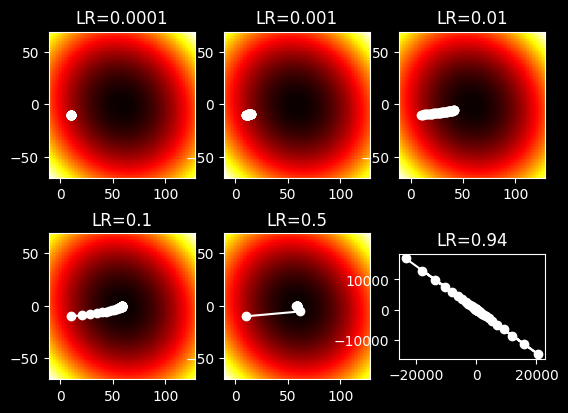

In [30]:
# Determine range for plotting
x_start, x_end, y_start, y_end = m-70, m+70, b-70, b+70
m_range = np.linspace(x_start, x_end, 100)
b_range = np.linspace(y_start, y_end, 100)

# Calculate loss function
mm, bb = np.meshgrid(m_range, b_range)
loss_surface = calc_cost_v(mm, bb)

# Plot learning curves
f, axarr = plt.subplots(2, 3)
for i in range(n_lr):
    axarr[i//3,i%3].set_title('LR={}'.format(learning_rates[i]))
    axarr[i//3,i%3].imshow(loss_surface, cmap='hot', interpolation='nearest', extent=[int(x_start), int(x_end), int(y_start), int(y_end)])
    axarr[i//3,i%3].plot(m_lists[i] ,b_lists[i], 'w-o')

### Bonus* - Polynomial regression

In [31]:
Y_poly = 3*X**2 - 2*X + 15

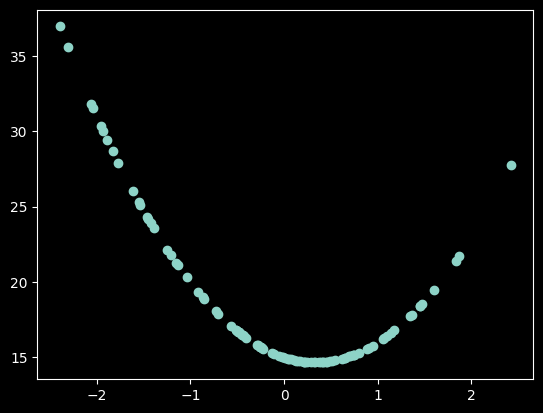

In [32]:
plt.scatter(X, Y_poly)

```
Try to modify the function "linear_regression" so now it will return parameters a,b,c such that minimize the cost:
```
$$Loss(b,m) = \frac{1}{n}\overset{n}{\underset{i=1}{\sum}} (a x_i^2 + bx_i + c - y^{(poly)}_i)^2$$


In [37]:
def linear_regression(X, y, a_current=0, b_current=0,c_current=0 ,epochs=10000, learning_rate=0.0001):
    N = float(len(y)) # Number of examples

    X2=X**2
    a_list = [a_current]
    b_list = [b_current]
    c_list = [c_current]

    # Perform Gradient (GD)
    for i in range(epochs):
        # Evaluate current model
        y_current = a_current*X2+b_current*X+c_current
        cost = np.mean(y_current-y)**2

        # Calculate Gradient
        a_gradient = np.mean(2*X2*(a_current*X2+b_current*X+c_current-y))
        b_gradient = np.mean(2*X*(a_current*X2+b_current*X+c_current-y))
        c_gradient = np.mean(2*(a_current*X2+b_current*X+c_current-y))

        # Make one GD step
        a_current = a_current-learning_rate*a_gradient
        b_current = b_current-learning_rate*b_gradient
        c_current = c_current-learning_rate*c_gradient

        a_list.append(a_current)
        b_list.append(b_current)
        c_list.append(c_current)


    return a_current, b_current,c_current, cost, a_list, b_list,c_list

In [69]:
a, b,c, cost, a_list, b_list,c_list = linear_regression(X, Y_poly, # The examples
                                               a_current=-10, b_current=-10,c_current=10 ,# The starting point for m and b
                                               learning_rate=0.03, # The learning rate, will be discussed later
                                               epochs=100 # Number of GD steps
                                              )

2.9411087343172166 -2.0542839247828812 15.110724614803859


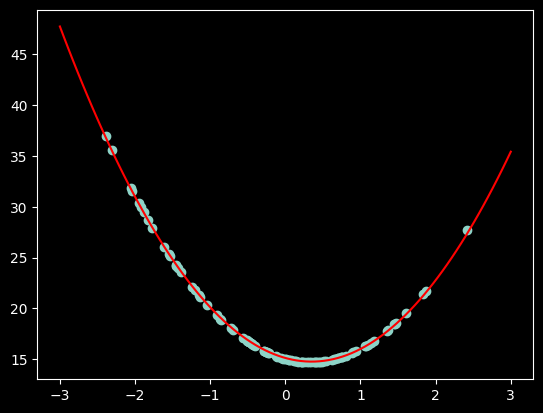

In [71]:
print(a,b,c)
# Plot data
plt.scatter(X, Y_poly)

# Plot model line
x1 = np.linspace(-3,3,100)
y1 = a * x1**2 + b*x1+c

plt.plot(x1,y1, 'r-')
plt.show()
